In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from glob import glob
import pickle as pkl
import os

## aux func

In [2]:
def plot_results(data):
    fig, axs = plt.subplots(nrows = 1, ncols = 3, figsize=(12, 4))

    y_min_delta = np.inf
    y_max_delta = -np.inf

    for key, value in data.items():
        df_mean = value.groupby("t").mean()
        df_std = value.groupby("t").std()

        y_min_delta = min(y_min_delta, (df_mean["delta"] - df_std["delta"]).min())
        y_min_delta = min(y_min_delta, (df_mean["delta_real"] - df_std["delta_real"]).min())
        y_max_delta = max(y_max_delta, (df_mean["delta"] + df_std["delta"]).max())
        y_max_delta = max(y_max_delta, (df_mean["delta_real"] + df_std["delta_real"]).max())

        axs[0].plot(df_mean.index, df_mean["bank_cash"], label=key)
        axs[0].fill_between(df_mean.index, df_mean["bank_cash"] - df_std["bank_cash"], df_mean["bank_cash"] + df_std["bank_cash"], alpha=0.2)
        axs[0].set_title("Bank Cash")
        axs[0].set_ylabel("Bank Cash")


        axs[1].plot(df_mean.index, df_mean["delta"], label=key)
        axs[1].fill_between(df_mean.index, df_mean["delta"] - df_std["delta"], df_mean["delta"] + df_std["delta"], alpha=0.2)
        axs[1].set_title("$\\tilde \\Delta$")
        axs[1].set_ylabel("$\\tilde \\Delta$")

        axs[2].plot(df_mean.index, df_mean["delta_real"], label=key)
        axs[2].fill_between(df_mean.index, df_mean["delta_real"] - df_std["delta_real"], df_mean["delta_real"] + df_std["delta_real"], alpha=0.2)
        axs[2].set_title("$\\Delta$")
        axs[2].set_ylabel("$\\Delta$")

    for i in range(3):
        axs[i].set_xlabel("Time step")
        axs[i].legend()

    for i in range(1, 3):
        axs[i].set_ylim(y_min_delta, y_max_delta)

    plt.tight_layout()
    plt.show()

In [3]:
def plot_correct_predictions(data):
    fig, axs = plt.subplots(nrows = 1, ncols = 4, figsize=(15, 4))

    y_min_delta = np.inf
    y_max_delta = -np.inf

    for key, value in data.items():
        df_mean = value.groupby("t").mean()
        df_std = value.groupby("t").std()

        y_min_delta = min(y_min_delta, (df_mean["delta"] - df_std["delta"]).min())
        y_min_delta = min(y_min_delta, (df_mean["delta_real"] - df_std["delta_real"]).min())
        y_max_delta = max(y_max_delta, (df_mean["delta"] + df_std["delta"]).max())
        y_max_delta = max(y_max_delta, (df_mean["delta_real"] + df_std["delta_real"]).max())

        # plot cunsum of label
        axs[0].plot(df_mean.index, np.cumsum(df_mean["label"]), label=key)
        axs[0].set_title("Percentage of positive labes")
        axs[0].set_ylabel("Percentage of positive labels")

        # plot cunsum of prediction
        axs[1].plot(df_mean.index, np.cumsum(df_mean["pred"]), label=key)
        axs[1].set_title("Percentage of positive predictions")
        axs[1].set_ylabel("Percentage of positive predictions")

        # plot cunsum of correct predictions
        axs[2].plot(df_mean.index, np.cumsum(df_mean["correct"]), label=key)
        axs[2].set_title("Percentage of correct predictions")
        axs[2].set_ylabel("Percentage of correct predictions")

        # plot the gap between delta and delta_real
        axs[3].plot(df_mean.index, df_mean["delta_real"] - df_mean["delta"], label=key)
        axs[3].set_title("Gap between $\\Delta$ and $\\tilde \\Delta$")
        axs[3].set_ylabel("Gap between $\\Delta$ and $\\tilde \\Delta$")

        # print the total sum of delta
        print(key)
        df_sum = value.groupby("ep").sum().mean()
        print(f"delta: {df_sum['delta']:.4f}")
        print(f"delta_real: {df_sum['delta_real']:.4f}")
        print(f"delta - delta_real: {np.abs(df_sum['delta'] - df_sum['delta_real']):.4f}")


    # on axis 3, plot a horizontal line at 0
    axs[3].axhline(0, color='black', linestyle='--')
    
    for i in range(4):
        axs[i].set_xlabel("Time step")
        axs[i].legend()

    #for i in range(1, 3):
    #    axs[i].set_ylim(y_min_delta, y_max_delta)

    plt.tight_layout()
    plt.show()

In [50]:
def confusion_matrix(data):

    for key, value in data.items():
        cm = np.zeros((2, 2))
        # do only in episode 0
        value = value[value["ep"] == 0]
        cm[0][0] = value[(value["label"] == 0) & (value["pred"] == 0)].shape[0]
        cm[0][1] = value[(value["label"] == 0) & (value["pred"] == 1)].shape[0]
        cm[1][0] = value[(value["label"] == 1) & (value["pred"] == 0)].shape[0]
        cm[1][1] = value[(value["label"] == 1) & (value["pred"] == 1)].shape[0]

        print(key)
        print(f"TP: {cm[1][1]}")
        print(f"TN: {cm[0][0]}")
        print(f"FP: {cm[0][1]}")
        print(f"FN: {cm[1][0]}")

In [40]:
def plot_group_metrics(data):
    data = data[data["ep"] == 0]
    #data = data.groupby(["group_id", "t"]).mean().reset_index()

    for g in [0, 1]:
        data_g = data[data["group_id"] == g]
        accepted = np.cumsum(data_g["action"]) / len(data_g)
        plt.plot(data_g["t"], accepted, label=f"Group {g}")
    
    plt.legend()
    plt.title("Accepted individuas")
    plt.show()



## results

In [88]:
env = "fico"
model_list = ["ppo", "pocar", "sellf"]
model_folders = [f"experiments/{env}/{model}/eval/eval_data.csv" for model in model_list]
data = {}
for folder in model_folders:
    model_name = folder.split("/")[-3]
    data[model_name] = pd.read_csv(folder)

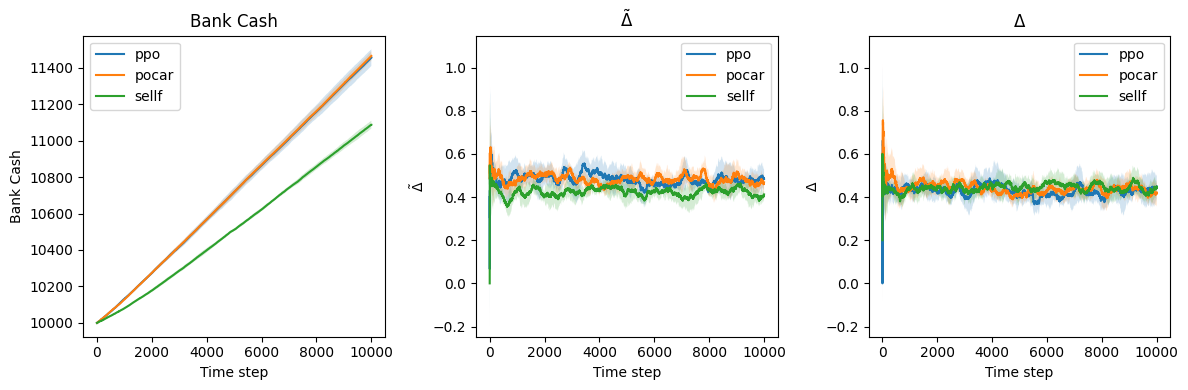

In [89]:
plot_results(data)

ppo
delta: 4824.1555
delta_real: 4288.6518
delta - delta_real: 535.5036
pocar
delta: 4833.8874
delta_real: 4424.3514
delta - delta_real: 409.5360
sellf
delta: 4232.8771
delta_real: 4428.6939
delta - delta_real: 195.8167


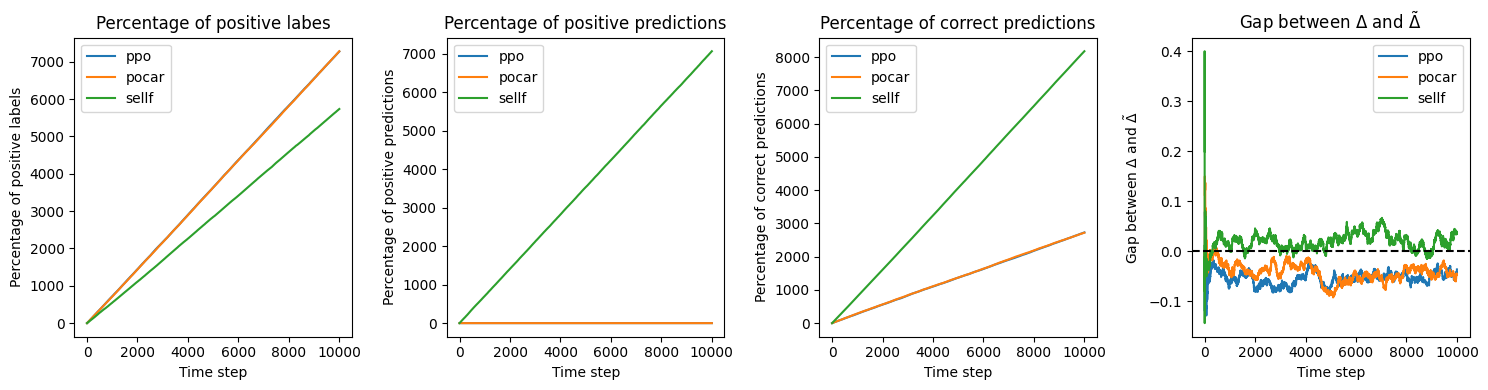

In [90]:
plot_correct_predictions(data)

In [74]:
confusion_matrix(data)

ppo
TP: 0.0
TN: 2770.0
FP: 0.0
FN: 7230.0
pocar
TP: 0.0
TN: 2700.0
FP: 0.0
FN: 7300.0
sellf
TP: 7299.0
TN: 0.0
FP: 2701.0
FN: 0.0


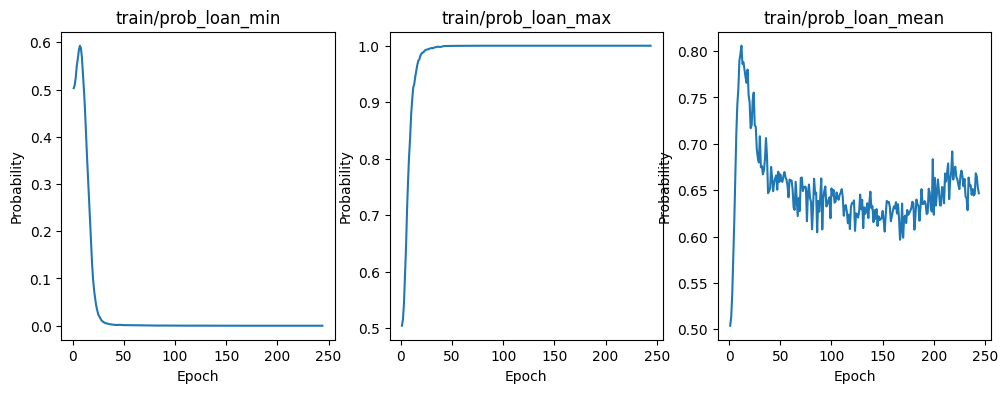

In [75]:
df_log = pd.read_csv("experiments/fico/sellf/models/progress.csv")

fig = plt.figure(figsize=(12, 4))

for i, col in enumerate(["train/prob_loan_min", "train/prob_loan_max", "train/prob_loan_mean"]):
    plt.subplot(1, 3, i + 1)
    plt.plot(df_log[col])
    plt.title(col)
    plt.xlabel("Epoch")
    plt.ylabel("Probability")

plt.show()
#plt.plot(df_log["train/prob"])
#df_log.columns

In [80]:
df_log

,time/iterations,rollout/ep_len_mean,rollout/ep_rew_mean,time/fps,time/total_timesteps,time/time_elapsed,train/pred_loss_g0,train/prob_loan_mean,train/pred_loss,train/accept_rate,...,train/n_updates,train/pred_loss_g1,train/policy_gradient_loss,train/approx_kl,train/learning_rate,train/pos_rate,train/value_loss,train/clip_range,train/clip_fraction,train/explained_variance
0,1,2000.0,-85.0000,144,2048,14,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,2000.0,-122.2500,126,4096,32,NaN,0.503759,0.821868,0.512207,...,10.0,0.838936,-0.000728,0.000116,0.00001,0.733887,1.471417,0.2,0.000000,0.006864
2,3,2000.0,-110.0000,121,6144,50,NaN,0.513156,0.760895,0.487305,...,20.0,0.783311,-0.000950,0.000305,0.00001,0.684082,1.996922,0.2,0.000000,0.002854
3,4,2000.0,-106.5625,118,8192,69,NaN,0.537450,0.773025,0.495605,...,30.0,0.790737,-0.003262,0.002140,0.00001,0.713379,1.444283,0.2,0.000000,0.016455
4,5,2000.0,-100.3500,116,10240,87,NaN,0.578543,0.734179,0.581055,...,40.0,0.747766,-0.003131,0.003684,0.00001,0.711914,1.051464,0.2,0.000000,0.049120
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
240,241,2000.0,278.6325,112,493568,4395,NaN,0.645814,0.125836,0.648438,...,2400.0,0.118033,-0.000553,0.000195,0.00001,0.715820,1.066661,0.2,0.002686,0.020155
241,242,2000.0,278.8350,112,495616,4413,NaN,0.668228,0.123151,0.669922,...,2410.0,0.113823,-0.000044,0.000038,0.00001,0.734863,1.055023,0.2,0.001416,0.044059
242,243,2000.0,279.0800,112,497664,4431,NaN,0.664707,0.097551,0.664551,...,2420.0,0.087097,-0.000151,0.000250,0.00001,0.736816,1.004689,0.2,0.002881,0.030366
243,244,2000.0,279.1225,112,499712,4450,NaN,0.652784,0.137499,0.652344,...,2430.0,0.125300,0.000009,0.000147,0.00001,0.725586,1.091765,0.2,0.001807,0.022506


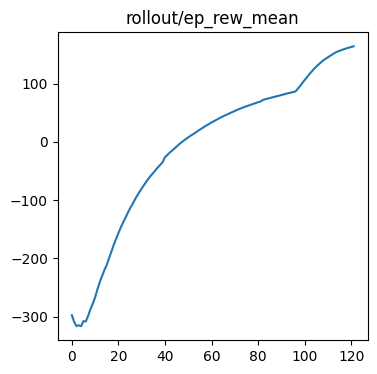

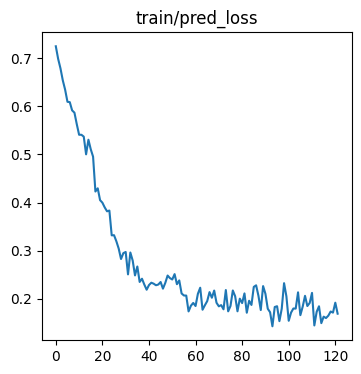

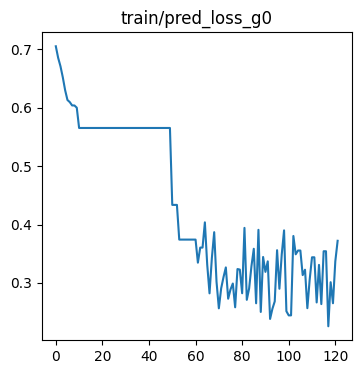

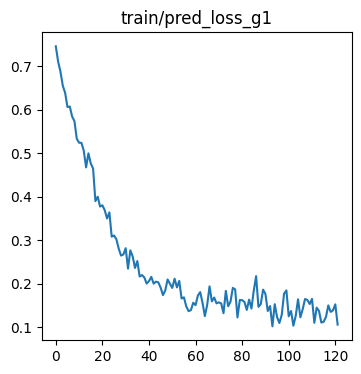

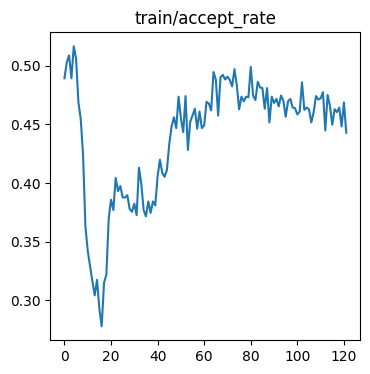

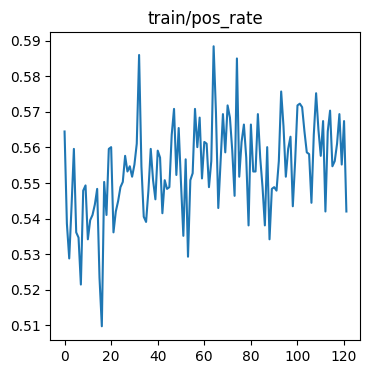

In [86]:
df_log = pd.read_csv("experiments/fico/sellf/models/progress.csv")

columns =[
    "rollout/ep_rew_mean",
    "train/pred_loss",
    "train/pred_loss_g0",
    "train/pred_loss_g1",
    "train/accept_rate",
    "train/pos_rate",
]

for col in columns:
    fig = plt.figure(figsize=(4, 4))

    val = df_log[col].values
    # if there is a nan value, replace it with the previous value
    new_val = []
    for i in range(1, len(val)):
        if np.isnan(val[i]):
            new_val.append(new_val[-1])
        else:
            new_val.append(val[i])
    
    plt.plot(new_val, label=col)
    plt.title(col)
    plt.show()


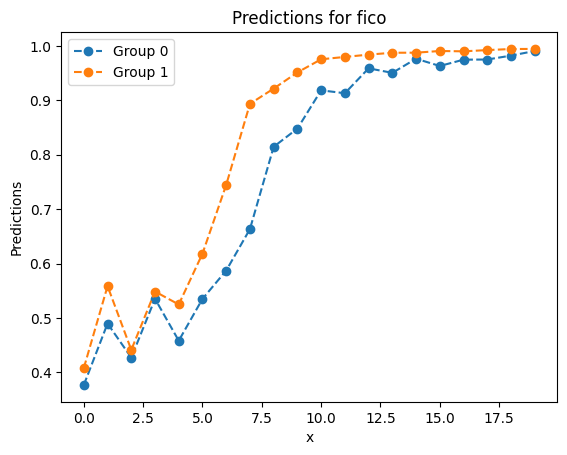

In [87]:
for env in ["fico"]:
    preds = {}
    model_folders = glob(f"experiments/{env}/sellf/eval/predictions.csv")
    for folder in model_folders:
        model_name = folder.split("/")[-3]
        preds[model_name] = pd.read_csv(folder)

    for df in preds.values():
        for g in range(2):
            df_ = df[df.g == g]
            df_ = df_.sort_values("x")
            plt.plot(df_.x, df_.pred, label=f"Group {g}", marker="o", linestyle="--")
    plt.title(f"Predictions for {env}")
    plt.xlabel("x")
    plt.ylabel("Predictions")
    plt.legend()
    plt.show()